In [92]:
import openpyxl
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3
from tabulate import tabulate
import numpy as np

### DF_INSIGHTS FUNCTION

This function takes a dataframe as parameter to return valuable insights on the dataframe in a table format using `tabulate` 



In [93]:
def df_insights(df):

    display(df)

    insights = [
        ['Count of Columns', df.shape[1]],
        ['Count of Rows', df.shape[0]],
        ['Missing Values', df.isna().sum().sum()]
        ]
    
    print('\n DF SUMMARY \n')
    print(tabulate(insights, headers=['Parameter', 'Value'], tablefmt='fancy_grid'))

    missingValues = df.isna().sum()
    missingValues = missingValues[missingValues > 0] # AI helped me to reason this line.


    missingValues_insights = [
        [eachCol, missingCount] for eachCol, missingCount in missingValues.items()

    ]
    
    if len(missingValues) > 0:
        print('\n MISSING VALUES \n')
        print(tabulate(missingValues_insights, headers=['COLUMN', 'COUNT OF ROWS MISSING VALUES'], tablefmt='fancy_grid'))

    datatypes_insights = [
        [eachCol, datatype] for eachCol, datatype in df.dtypes.items()
    ]

    print('\n DATATYPES \n')
    print(tabulate(datatypes_insights, headers=['COLUMN', 'DTYPE'], tablefmt='fancy_grid'))

### DF_CLEANUP FUNCTION

This function takes a dataframe as parameter and standardize values in the dataframe by converting them to uppercase, trimming extra spaces, and using regular expressions to remove 'junk' data from strings. <br>
<br>
The exception is the `COUNTY_FIPS` column which although contain numeric values, its data type was intentionally stored as a string, since its not used for calculations. <br>
<br>
Lastly, `zfill` was applied to this column to pad leading zeroes to the values, ensuring its values are consistently five digits long. 



In [94]:
def df_cleanup(df):
    for eachCol in df.columns:
        if df[eachCol].dtype == 'string' and eachCol not in ['COUNTY_FIPS', 'RUCC_DESCRIPTION', 'RUCC_SEER', 'DX_CODE', 'HISTOLOGY_ICD-O-3', 'BEHAVIOR','AGE_AT_DIAGNOSTIC']:
            df[eachCol] = df[eachCol].str.upper().str.strip().str.replace(r'\s+', ' ', regex=True).str.replace(r'[^A-Z\s\.,-]', '', regex=True)
  
    if 'COUNTY_FIPS' in df.columns:
        df['COUNTY_FIPS'] = df['COUNTY_FIPS'].astype('string').str.zfill(5)

    duplicate_count = df.duplicated().sum()

    df.drop_duplicates(keep='first', inplace=True)

    if duplicate_count == 1:
        print(f'{duplicate_count} duplicate was removed. {len(df)} rows remain')
    elif duplicate_count > 1:
        print(f'{duplicate_count} duplicates were removed. {len(df)} rows remain')
    else:
        print(f'No duplicates were found. {len(df)} rows remain ')

    df.reset_index(drop=True, inplace=True)

    df_insights(df)

    return df

Importing Datasets

# UV_EXPOSURE DATASET 

In [95]:


uv_exposure = pd.read_excel('../datasets/uv-county-exposure.xlsx', sheet_name='UV_County_2000-2024', dtype={'COUNTY_FIPS': str})
uv_exposure.rename({'COUNTY NAME': 'COUNTY_NAME', 
                    'STATENAME': 'STATE_NAME',
                    'UV_ Wh/m² (2000-2004)': 'UV_2000_2004',
                    'UV_ Wh/m² (2005-2009)': 'UV_2005_2009',
                    'UV_ Wh/m² (2010-2014)': 'UV_2010_2014',
                    'UV_ Wh/m² (2015-2019)': 'UV_2015_2019',
                    'UV_ Wh/m² (2020_2024)': 'UV_2020_2024'}, axis=1, inplace=True)

uv_exposure = uv_exposure.sort_values(['STATE_NAME', 'COUNTY_NAME'])
uv_exposure




,STATE_NAME,COUNTY_NAME,COUNTY_FIPS,UV_2000_2004,UV_2005_2009,UV_2010_2014,UV_2015_2019,UV_2020_2024
2734,Alabama,Autauga,1001,4781.877818,4774.090182,4843.185939,4701.004606,4785.906061
2159,Alabama,Baldwin,1003,4916.409224,4904.892424,4934.852894,4764.348800,4814.548819
565,Alabama,Barbour,1005,4875.885667,4862.169667,4908.160333,4786.408667,4833.696667
974,Alabama,Bibb,1007,4727.518560,4706.299680,4785.613440,4625.073600,4726.646400
2232,Alabama,Blount,1009,4643.034462,4606.273385,4687.476000,4574.497846,4665.236538
...,...,...,...,...,...,...,...,...
1527,Wyoming,Sweetwater,56037,4780.547753,4819.313629,4731.694674,4753.577473,4910.167898
1517,Wyoming,Teton,56039,4294.326031,4282.941613,4162.277026,4303.009508,4529.784895
2234,Wyoming,Uinta,56041,4730.583808,4797.226752,4687.229184,4736.682624,4936.341280
1990,Wyoming,Washakie,56043,4558.186982,4545.855054,4427.304308,4473.671815,4565.537275


In [96]:
uv_exposure.columns

Index(['STATE_NAME', 'COUNTY_NAME', 'COUNTY_FIPS', 'UV_2000_2004',
       'UV_2005_2009', 'UV_2010_2014', 'UV_2015_2019', 'UV_2020_2024'],
      dtype='str')

In [97]:
df_insights(uv_exposure)

,STATE_NAME,COUNTY_NAME,COUNTY_FIPS,UV_2000_2004,UV_2005_2009,UV_2010_2014,UV_2015_2019,UV_2020_2024
2734,Alabama,Autauga,1001,4781.877818,4774.090182,4843.185939,4701.004606,4785.906061
2159,Alabama,Baldwin,1003,4916.409224,4904.892424,4934.852894,4764.348800,4814.548819
565,Alabama,Barbour,1005,4875.885667,4862.169667,4908.160333,4786.408667,4833.696667
974,Alabama,Bibb,1007,4727.518560,4706.299680,4785.613440,4625.073600,4726.646400
2232,Alabama,Blount,1009,4643.034462,4606.273385,4687.476000,4574.497846,4665.236538
...,...,...,...,...,...,...,...,...
1527,Wyoming,Sweetwater,56037,4780.547753,4819.313629,4731.694674,4753.577473,4910.167898
1517,Wyoming,Teton,56039,4294.326031,4282.941613,4162.277026,4303.009508,4529.784895
2234,Wyoming,Uinta,56041,4730.583808,4797.226752,4687.229184,4736.682624,4936.341280
1990,Wyoming,Washakie,56043,4558.186982,4545.855054,4427.304308,4473.671815,4565.537275



 DF SUMMARY 

╒══════════════════╤═════════╕
│ Parameter        │   Value │
╞══════════════════╪═════════╡
│ Count of Columns │       8 │
├──────────────────┼─────────┤
│ Count of Rows    │    3107 │
├──────────────────┼─────────┤
│ Missing Values   │       0 │
╘══════════════════╧═════════╛

 DATATYPES 

╒══════════════╤═════════╕
│ COLUMN       │ DTYPE   │
╞══════════════╪═════════╡
│ STATE_NAME   │ str     │
├──────────────┼─────────┤
│ COUNTY_NAME  │ str     │
├──────────────┼─────────┤
│ COUNTY_FIPS  │ str     │
├──────────────┼─────────┤
│ UV_2000_2004 │ float64 │
├──────────────┼─────────┤
│ UV_2005_2009 │ float64 │
├──────────────┼─────────┤
│ UV_2010_2014 │ float64 │
├──────────────┼─────────┤
│ UV_2015_2019 │ float64 │
├──────────────┼─────────┤
│ UV_2020_2024 │ float64 │
╘══════════════╧═════════╛


In [98]:
df_cleanup(uv_exposure)

No duplicates were found. 3107 rows remain 


,STATE_NAME,COUNTY_NAME,COUNTY_FIPS,UV_2000_2004,UV_2005_2009,UV_2010_2014,UV_2015_2019,UV_2020_2024
0,ALABAMA,AUTAUGA,01001,4781.877818,4774.090182,4843.185939,4701.004606,4785.906061
1,ALABAMA,BALDWIN,01003,4916.409224,4904.892424,4934.852894,4764.348800,4814.548819
2,ALABAMA,BARBOUR,01005,4875.885667,4862.169667,4908.160333,4786.408667,4833.696667
3,ALABAMA,BIBB,01007,4727.518560,4706.299680,4785.613440,4625.073600,4726.646400
4,ALABAMA,BLOUNT,01009,4643.034462,4606.273385,4687.476000,4574.497846,4665.236538
...,...,...,...,...,...,...,...,...
3102,WYOMING,SWEETWATER,56037,4780.547753,4819.313629,4731.694674,4753.577473,4910.167898
3103,WYOMING,TETON,56039,4294.326031,4282.941613,4162.277026,4303.009508,4529.784895
3104,WYOMING,UINTA,56041,4730.583808,4797.226752,4687.229184,4736.682624,4936.341280
3105,WYOMING,WASHAKIE,56043,4558.186982,4545.855054,4427.304308,4473.671815,4565.537275



 DF SUMMARY 

╒══════════════════╤═════════╕
│ Parameter        │   Value │
╞══════════════════╪═════════╡
│ Count of Columns │       8 │
├──────────────────┼─────────┤
│ Count of Rows    │    3107 │
├──────────────────┼─────────┤
│ Missing Values   │       0 │
╘══════════════════╧═════════╛

 DATATYPES 

╒══════════════╤═════════╕
│ COLUMN       │ DTYPE   │
╞══════════════╪═════════╡
│ STATE_NAME   │ str     │
├──────────────┼─────────┤
│ COUNTY_NAME  │ str     │
├──────────────┼─────────┤
│ COUNTY_FIPS  │ string  │
├──────────────┼─────────┤
│ UV_2000_2004 │ float64 │
├──────────────┼─────────┤
│ UV_2005_2009 │ float64 │
├──────────────┼─────────┤
│ UV_2010_2014 │ float64 │
├──────────────┼─────────┤
│ UV_2015_2019 │ float64 │
├──────────────┼─────────┤
│ UV_2020_2024 │ float64 │
╘══════════════╧═════════╛


,STATE_NAME,COUNTY_NAME,COUNTY_FIPS,UV_2000_2004,UV_2005_2009,UV_2010_2014,UV_2015_2019,UV_2020_2024
0,ALABAMA,AUTAUGA,01001,4781.877818,4774.090182,4843.185939,4701.004606,4785.906061
1,ALABAMA,BALDWIN,01003,4916.409224,4904.892424,4934.852894,4764.348800,4814.548819
2,ALABAMA,BARBOUR,01005,4875.885667,4862.169667,4908.160333,4786.408667,4833.696667
3,ALABAMA,BIBB,01007,4727.518560,4706.299680,4785.613440,4625.073600,4726.646400
4,ALABAMA,BLOUNT,01009,4643.034462,4606.273385,4687.476000,4574.497846,4665.236538
...,...,...,...,...,...,...,...,...
3102,WYOMING,SWEETWATER,56037,4780.547753,4819.313629,4731.694674,4753.577473,4910.167898
3103,WYOMING,TETON,56039,4294.326031,4282.941613,4162.277026,4303.009508,4529.784895
3104,WYOMING,UINTA,56041,4730.583808,4797.226752,4687.229184,4736.682624,4936.341280
3105,WYOMING,WASHAKIE,56043,4558.186982,4545.855054,4427.304308,4473.671815,4565.537275


# MELANOMA INCIDENCE WITH COUNTY INFO DATASET

In [99]:


melanoma_incidence = pd.read_csv('../datasets/melanoma-county-incidence.csv', dtype={'FIPS': str}, skiprows=8, skipfooter=35, engine='python')
melanoma_incidence.drop(columns=['Lower 95% Confidence Interval', 
                                 'Upper 95% Confidence Interval', 
                                 'CI*Rank([rank note])', 
                                 'Lower CI (CI*Rank)', 
                                 'Upper CI (CI*Rank)', 
                                 'Recent 5-Year Trend ([trend note]) in Incidence Rates', 
                                 'Lower 95% Confidence Interval.1', 
                                 'Upper 95% Confidence Interval.1',
                                 'Recent Trend'], inplace=True)
melanoma_incidence.rename({'FIPS': 'COUNTY_FIPS',
                           '2023 Rural-Urban Continuum Codes([rural urban note])': 'RURAL_URBAN_NOTE',
                           'Age-Adjusted Incidence Rate([rate note]) - cases per 100,000': 'AGE_RATE_PER100K', 
                           'Average Annual Count': 'AVG_ANNUAL_COUNT'}, axis=1, inplace=True)
melanoma_incidence = melanoma_incidence[melanoma_incidence['COUNTY_FIPS'] != '00000'] # drops the annual agreggate row that has COUNTY_FIPS = '00000'

# SPLIT COUNTY COLUMN INTO COUNTY AND STATE

melanoma_incidence['COUNTY_NAME'] = melanoma_incidence['County'].str.split(', ', expand=True)[0]
melanoma_incidence['STATE_NAME'] = melanoma_incidence['County'].str.split(', ', expand=True)[1]
melanoma_incidence.insert(0, 'STATE_NAME', melanoma_incidence.pop('STATE_NAME'))
melanoma_incidence.insert(1, 'COUNTY_NAME', melanoma_incidence.pop('COUNTY_NAME'))
melanoma_incidence.drop(columns=['County'], inplace=True)

# CLEANING UP COUNTY COLUMN

melanoma_incidence['COUNTY_NAME'] = melanoma_incidence['COUNTY_NAME'].replace(' County', '', regex=True)

melanoma_incidence = melanoma_incidence.sort_values(['COUNTY_FIPS'])
melanoma_incidence


,STATE_NAME,COUNTY_NAME,COUNTY_FIPS,RURAL_URBAN_NOTE,AGE_RATE_PER100K,AVG_ANNUAL_COUNT
1096,Alabama(6),Autauga,01001,Urban,24,16
217,Alabama(6),Baldwin,01003,Urban,37.2,115
1209,Alabama(6),Barbour,01005,Rural,22.8,8
1909,Alabama(6),Bibb,01007,Urban,15.5,4
1569,Alabama(6),Blount,01009,Urban,19.4,14
...,...,...,...,...,...,...
292,Wyoming(6),Teton,56039,Rural,35.2,10
1836,Wyoming(6),Uinta,56041,Rural,16.4,4
3090,Wyoming(6),Washakie,56043,Rural,*,3 or fewer
3108,Wyoming(6),Weston,56045,Rural,*,3 or fewer


In [100]:
melanoma_incidence['AGE_RATE_PER100K'].unique()

<StringArray>
[  '24 ', '37.2 ', '22.8 ', '15.5 ', '19.4 ',    '* ', '17.9 ', '25.2 ',
  '9.1 ', '17.5 ',
 ...
 '68.1 ', '40.5 ',  '7.5 ',  '8.4 ',  '9.7 ', '47.6 ',   '63 ', '27.7 ',
 '35.2 ',  '3.3 ']
Length: 417, dtype: str

In [101]:
melanoma_incidence['AVG_ANNUAL_COUNT'] = (melanoma_incidence['AVG_ANNUAL_COUNT'].replace('3 or fewer', 1.5))
melanoma_incidence['AVG_ANNUAL_COUNT'].unique()

array(['16', '115', '8', '4', '14', 1.5, '5', '33', '6', '10', '7', '3',
       '29', '15', '17', '28', '9', '27', '13', '39', '20', '120', '25',
       '26', '37', '112', '101', '38', '44', '23', '53', '21', '51', '11',
       '56', '34', '19', '1665', '81', '22', '485', '179', '161', '77',
       '24', '111', '47', '36', '50', '366', '97', '420', '106', '178',
       '152', '1397', '40', '221', '122', '59', '66', '1102', '216',
       '667', '393', '355', '1104', '212', '140', '210', '254', '135',
       '151', '83', '283', '119', '58', '276', '49', '76', '142', '104',
       '12', '136', '129', '171', '60', '65', '63', '228', '207', '52',
       '192', '42', '54', '158', '130', '68', '72', '310', '483', '96',
       '88', '256', '286', '117', '73', '423', '141', '143', '476', '257',
       '163', '64', '234', '604', '260', '479', '306', '145', '71', '335',
       '102', '35', '100', '18', '205', '131', '123', '303', '30', '103',
       '48', '32', '233', '70', '193', '61', '31', '92

In [102]:
# '3 or fewer' values were turned into a safe 1.5 value - nan and 'data not available will also become NaN for calculations
melanoma_incidence['AVG_ANNUAL_COUNT'] = (melanoma_incidence['AVG_ANNUAL_COUNT'].replace('3 or fewer', 1.5))
melanoma_incidence

,STATE_NAME,COUNTY_NAME,COUNTY_FIPS,RURAL_URBAN_NOTE,AGE_RATE_PER100K,AVG_ANNUAL_COUNT
1096,Alabama(6),Autauga,01001,Urban,24,16
217,Alabama(6),Baldwin,01003,Urban,37.2,115
1209,Alabama(6),Barbour,01005,Rural,22.8,8
1909,Alabama(6),Bibb,01007,Urban,15.5,4
1569,Alabama(6),Blount,01009,Urban,19.4,14
...,...,...,...,...,...,...
292,Wyoming(6),Teton,56039,Rural,35.2,10
1836,Wyoming(6),Uinta,56041,Rural,16.4,4
3090,Wyoming(6),Washakie,56043,Rural,*,1.5
3108,Wyoming(6),Weston,56045,Rural,*,1.5


In [103]:
df_insights(melanoma_incidence)

,STATE_NAME,COUNTY_NAME,COUNTY_FIPS,RURAL_URBAN_NOTE,AGE_RATE_PER100K,AVG_ANNUAL_COUNT
1096,Alabama(6),Autauga,01001,Urban,24,16
217,Alabama(6),Baldwin,01003,Urban,37.2,115
1209,Alabama(6),Barbour,01005,Rural,22.8,8
1909,Alabama(6),Bibb,01007,Urban,15.5,4
1569,Alabama(6),Blount,01009,Urban,19.4,14
...,...,...,...,...,...,...
292,Wyoming(6),Teton,56039,Rural,35.2,10
1836,Wyoming(6),Uinta,56041,Rural,16.4,4
3090,Wyoming(6),Washakie,56043,Rural,*,1.5
3108,Wyoming(6),Weston,56045,Rural,*,1.5



 DF SUMMARY 

╒══════════════════╤═════════╕
│ Parameter        │   Value │
╞══════════════════╪═════════╡
│ Count of Columns │       6 │
├──────────────────┼─────────┤
│ Count of Rows    │    3143 │
├──────────────────┼─────────┤
│ Missing Values   │       2 │
╘══════════════════╧═════════╛

 MISSING VALUES 

╒════════════╤════════════════════════════════╕
│ COLUMN     │   COUNT OF ROWS MISSING VALUES │
╞════════════╪════════════════════════════════╡
│ STATE_NAME │                              2 │
╘════════════╧════════════════════════════════╛

 DATATYPES 

╒══════════════════╤═════════╕
│ COLUMN           │ DTYPE   │
╞══════════════════╪═════════╡
│ STATE_NAME       │ str     │
├──────────────────┼─────────┤
│ COUNTY_NAME      │ str     │
├──────────────────┼─────────┤
│ COUNTY_FIPS      │ str     │
├──────────────────┼─────────┤
│ RURAL_URBAN_NOTE │ str     │
├──────────────────┼─────────┤
│ AGE_RATE_PER100K │ str     │
├──────────────────┼─────────┤
│ AVG_ANNUAL_COUNT │ object  │

### Issue observed when normalizing data types:

There were a coupe of rows that had no data available for columns `AGE_RATE_PER100K` and `AVG_ANNUAL_COUNT`.<br>
I did not want to `.drop()` these rows, because I thought values would be skewed.<br>
Instead, used this guidance found <a href="https://stackoverflow.com/questions/36814100/pandas-to-numeric-for-multiple-columns" target="_blank">here</a> to apply `pd.to_numeric()` and then convert selected columns to numeric dtypes.

In [104]:
str_to_nan = ["AGE_RATE_PER100K", "AVG_ANNUAL_COUNT"]
melanoma_incidence[str_to_nan] = melanoma_incidence[str_to_nan].apply(pd.to_numeric, errors="coerce")

melanoma_incidence

,STATE_NAME,COUNTY_NAME,COUNTY_FIPS,RURAL_URBAN_NOTE,AGE_RATE_PER100K,AVG_ANNUAL_COUNT
1096,Alabama(6),Autauga,01001,Urban,24.0,16.0
217,Alabama(6),Baldwin,01003,Urban,37.2,115.0
1209,Alabama(6),Barbour,01005,Rural,22.8,8.0
1909,Alabama(6),Bibb,01007,Urban,15.5,4.0
1569,Alabama(6),Blount,01009,Urban,19.4,14.0
...,...,...,...,...,...,...
292,Wyoming(6),Teton,56039,Rural,35.2,10.0
1836,Wyoming(6),Uinta,56041,Rural,16.4,4.0
3090,Wyoming(6),Washakie,56043,Rural,NaN,1.5
3108,Wyoming(6),Weston,56045,Rural,NaN,1.5


In [105]:
df_insights(melanoma_incidence)

,STATE_NAME,COUNTY_NAME,COUNTY_FIPS,RURAL_URBAN_NOTE,AGE_RATE_PER100K,AVG_ANNUAL_COUNT
1096,Alabama(6),Autauga,01001,Urban,24.0,16.0
217,Alabama(6),Baldwin,01003,Urban,37.2,115.0
1209,Alabama(6),Barbour,01005,Rural,22.8,8.0
1909,Alabama(6),Bibb,01007,Urban,15.5,4.0
1569,Alabama(6),Blount,01009,Urban,19.4,14.0
...,...,...,...,...,...,...
292,Wyoming(6),Teton,56039,Rural,35.2,10.0
1836,Wyoming(6),Uinta,56041,Rural,16.4,4.0
3090,Wyoming(6),Washakie,56043,Rural,NaN,1.5
3108,Wyoming(6),Weston,56045,Rural,NaN,1.5



 DF SUMMARY 

╒══════════════════╤═════════╕
│ Parameter        │   Value │
╞══════════════════╪═════════╡
│ Count of Columns │       6 │
├──────────────────┼─────────┤
│ Count of Rows    │    3143 │
├──────────────────┼─────────┤
│ Missing Values   │    1158 │
╘══════════════════╧═════════╛

 MISSING VALUES 

╒══════════════════╤════════════════════════════════╕
│ COLUMN           │   COUNT OF ROWS MISSING VALUES │
╞══════════════════╪════════════════════════════════╡
│ STATE_NAME       │                              2 │
├──────────────────┼────────────────────────────────┤
│ AGE_RATE_PER100K │                            959 │
├──────────────────┼────────────────────────────────┤
│ AVG_ANNUAL_COUNT │                            197 │
╘══════════════════╧════════════════════════════════╛

 DATATYPES 

╒══════════════════╤═════════╕
│ COLUMN           │ DTYPE   │
╞══════════════════╪═════════╡
│ STATE_NAME       │ str     │
├──────────────────┼─────────┤
│ COUNTY_NAME      │ str     │
├

In [106]:
melanoma_incidence[melanoma_incidence['STATE_NAME'].isna()]

,STATE_NAME,COUNTY_NAME,COUNTY_FIPS,RURAL_URBAN_NOTE,AGE_RATE_PER100K,AVG_ANNUAL_COUNT
2146,NaN,District of Columbia(6),11001,Urban,10.0,68.0
2184,NaN,Puerto Rico(6),72001,Urban,3.3,132.0


These are the only two rows that have null values in this dataset. <br>
The `COUNTY_FIPS` code for this row is `72001`.<br>
Let's evaluate if there is a UV exposure measurement for this county in the `uv_exposure` df:<br>


In [107]:
if uv_exposure[uv_exposure['COUNTY_FIPS'] == '11001'].empty:
    print('FIPS CODE NOT FOUND')
else:
    print('UV INDEX MEASUREMENT FOUND FOR THIS FIPS CODE')

uv_exposure[uv_exposure['COUNTY_FIPS'] == '11001']

UV INDEX MEASUREMENT FOUND FOR THIS FIPS CODE


,STATE_NAME,COUNTY_NAME,COUNTY_FIPS,UV_2000_2004,UV_2005_2009,UV_2010_2014,UV_2015_2019,UV_2020_2024
290,DISTRICT OF COLUMBIA,DISTRICT OF COLUMBIA,11001,4286.810182,4233.748364,4291.252364,4154.570182,4235.43


For this row, we can use `.loc` to use the `COUNTY_FIPS` value to target the row value in the `STATE` column that should be filled in with a valid name:

In [108]:
melanoma_incidence.loc[melanoma_incidence['COUNTY_FIPS'] == '11001', 'STATE_NAME'] =  'District of Columbia'

In [109]:
melanoma_incidence.loc[2146]

STATE_NAME             District of Columbia
COUNTY_NAME         District of Columbia(6)
COUNTY_FIPS                           11001
RURAL_URBAN_NOTE                      Urban
AGE_RATE_PER100K                       10.0
AVG_ANNUAL_COUNT                       68.0
Name: 2146, dtype: object

For the second row with a NaN value, we will follow the same approach:

In [110]:
if uv_exposure[uv_exposure['COUNTY_FIPS'] == '72001' ].empty:
    print('FIPS CODE NOT FOUND')
else:
    print('UV INDEX MEASUREMENT FOUND FOR THIS FIPS CODE')


FIPS CODE NOT FOUND


Since there is no measurement for this county, we can drop this row from the `melanoma_incidence` dataset.

In [111]:
melanoma_incidence.dropna(subset=['STATE_NAME'], inplace=True)
melanoma_incidence.isna().sum()

STATE_NAME            0
COUNTY_NAME           0
COUNTY_FIPS           0
RURAL_URBAN_NOTE      0
AGE_RATE_PER100K    959
AVG_ANNUAL_COUNT    197
dtype: int64

In [112]:
df_insights(melanoma_incidence)

,STATE_NAME,COUNTY_NAME,COUNTY_FIPS,RURAL_URBAN_NOTE,AGE_RATE_PER100K,AVG_ANNUAL_COUNT
1096,Alabama(6),Autauga,01001,Urban,24.0,16.0
217,Alabama(6),Baldwin,01003,Urban,37.2,115.0
1209,Alabama(6),Barbour,01005,Rural,22.8,8.0
1909,Alabama(6),Bibb,01007,Urban,15.5,4.0
1569,Alabama(6),Blount,01009,Urban,19.4,14.0
...,...,...,...,...,...,...
1022,Wyoming(6),Sweetwater,56037,Rural,24.8,11.0
292,Wyoming(6),Teton,56039,Rural,35.2,10.0
1836,Wyoming(6),Uinta,56041,Rural,16.4,4.0
3090,Wyoming(6),Washakie,56043,Rural,NaN,1.5



 DF SUMMARY 

╒══════════════════╤═════════╕
│ Parameter        │   Value │
╞══════════════════╪═════════╡
│ Count of Columns │       6 │
├──────────────────┼─────────┤
│ Count of Rows    │    3142 │
├──────────────────┼─────────┤
│ Missing Values   │    1156 │
╘══════════════════╧═════════╛

 MISSING VALUES 

╒══════════════════╤════════════════════════════════╕
│ COLUMN           │   COUNT OF ROWS MISSING VALUES │
╞══════════════════╪════════════════════════════════╡
│ AGE_RATE_PER100K │                            959 │
├──────────────────┼────────────────────────────────┤
│ AVG_ANNUAL_COUNT │                            197 │
╘══════════════════╧════════════════════════════════╛

 DATATYPES 

╒══════════════════╤═════════╕
│ COLUMN           │ DTYPE   │
╞══════════════════╪═════════╡
│ STATE_NAME       │ str     │
├──────────────────┼─────────┤
│ COUNTY_NAME      │ str     │
├──────────────────┼─────────┤
│ COUNTY_FIPS      │ str     │
├──────────────────┼─────────┤
│ RURAL_URBAN_NO

In [113]:
df_cleanup(melanoma_incidence)

No duplicates were found. 3142 rows remain 


,STATE_NAME,COUNTY_NAME,COUNTY_FIPS,RURAL_URBAN_NOTE,AGE_RATE_PER100K,AVG_ANNUAL_COUNT
0,ALABAMA,AUTAUGA,01001,URBAN,24.0,16.0
1,ALABAMA,BALDWIN,01003,URBAN,37.2,115.0
2,ALABAMA,BARBOUR,01005,RURAL,22.8,8.0
3,ALABAMA,BIBB,01007,URBAN,15.5,4.0
4,ALABAMA,BLOUNT,01009,URBAN,19.4,14.0
...,...,...,...,...,...,...
3137,WYOMING,SWEETWATER,56037,RURAL,24.8,11.0
3138,WYOMING,TETON,56039,RURAL,35.2,10.0
3139,WYOMING,UINTA,56041,RURAL,16.4,4.0
3140,WYOMING,WASHAKIE,56043,RURAL,NaN,1.5



 DF SUMMARY 

╒══════════════════╤═════════╕
│ Parameter        │   Value │
╞══════════════════╪═════════╡
│ Count of Columns │       6 │
├──────────────────┼─────────┤
│ Count of Rows    │    3142 │
├──────────────────┼─────────┤
│ Missing Values   │    1156 │
╘══════════════════╧═════════╛

 MISSING VALUES 

╒══════════════════╤════════════════════════════════╕
│ COLUMN           │   COUNT OF ROWS MISSING VALUES │
╞══════════════════╪════════════════════════════════╡
│ AGE_RATE_PER100K │                            959 │
├──────────────────┼────────────────────────────────┤
│ AVG_ANNUAL_COUNT │                            197 │
╘══════════════════╧════════════════════════════════╛

 DATATYPES 

╒══════════════════╤═════════╕
│ COLUMN           │ DTYPE   │
╞══════════════════╪═════════╡
│ STATE_NAME       │ str     │
├──────────────────┼─────────┤
│ COUNTY_NAME      │ str     │
├──────────────────┼─────────┤
│ COUNTY_FIPS      │ string  │
├──────────────────┼─────────┤
│ RURAL_URBAN_NO

,STATE_NAME,COUNTY_NAME,COUNTY_FIPS,RURAL_URBAN_NOTE,AGE_RATE_PER100K,AVG_ANNUAL_COUNT
0,ALABAMA,AUTAUGA,01001,URBAN,24.0,16.0
1,ALABAMA,BALDWIN,01003,URBAN,37.2,115.0
2,ALABAMA,BARBOUR,01005,RURAL,22.8,8.0
3,ALABAMA,BIBB,01007,URBAN,15.5,4.0
4,ALABAMA,BLOUNT,01009,URBAN,19.4,14.0
...,...,...,...,...,...,...
3137,WYOMING,SWEETWATER,56037,RURAL,24.8,11.0
3138,WYOMING,TETON,56039,RURAL,35.2,10.0
3139,WYOMING,UINTA,56041,RURAL,16.4,4.0
3140,WYOMING,WASHAKIE,56043,RURAL,NaN,1.5


# RURAL URBAN CONTINUUM CODES DATASET

In [114]:


continuum_codes = pd.read_excel('../datasets/rural-urban-continuum-codes-2023.xlsx',dtype={'FIPS': str})
continuum_codes.rename({'FIPS': 'COUNTY_FIPS', 
                        'State': 'STATE_ABB',
                        'County_Name': 'COUNTY_NAME',
                        'Population_2020': 'POPULATION_COUNT',
                        'Description': 'RUCC_DESCRIPTION'}, axis=1, inplace=True)
continuum_codes['COUNTY_NAME'] = continuum_codes['COUNTY_NAME'].replace(' County', '', regex=True)

# CHANGING COLUMN ORDERS FOR BETTER DESIGN

continuum_codes.insert(0, 'STATE_ABB', continuum_codes.pop('STATE_ABB'))
continuum_codes.insert(1, 'COUNTY_NAME', continuum_codes.pop('COUNTY_NAME'))

continuum_codes

,STATE_ABB,COUNTY_NAME,COUNTY_FIPS,POPULATION_COUNT,RUCC_2023,RUCC_DESCRIPTION
0,AL,Autauga,01001,58805,2.0,"Metro - Counties in metro areas of 250,000 to ..."
1,AL,Baldwin,01003,231767,3.0,Metro - Counties in metro areas of fewer than ...
2,AL,Barbour,01005,25223,6.0,"Nonmetro - Urban population of 5,000 to 20,000..."
3,AL,Bibb,01007,22293,1.0,Metro - Counties in metro areas of 1 million p...
4,AL,Blount,01009,59134,1.0,Metro - Counties in metro areas of 1 million p...
...,...,...,...,...,...,...
3230,PR,Yabucoa Municipio,72151,30426,1.0,Metro - Counties in metro areas of 1 million p...
3231,PR,Yauco Municipio,72153,34172,2.0,"Metro - Counties in metro areas of 250,000 to ..."
3232,VI,St. Croix Island,78010,41004,5.0,"Nonmetro - Urban population of 20,000 or more,..."
3233,VI,St. John Island,78020,3881,9.0,"Nonmetro - Urban population of fewer than 5,00..."


In [115]:
continuum_codes.isna().sum()

STATE_ABB           0
COUNTY_NAME         0
COUNTY_FIPS         0
POPULATION_COUNT    0
RUCC_2023           2
RUCC_DESCRIPTION    0
dtype: int64

In [116]:
continuum_codes[continuum_codes['RUCC_2023'].isna()]

,STATE_ABB,COUNTY_NAME,COUNTY_FIPS,POPULATION_COUNT,RUCC_2023,RUCC_DESCRIPTION
3146,AS,Rose Island,60030,0,NaN,Not Applicable
3147,AS,Swains Island,60040,0,NaN,Not Applicable


These two rows have null values for Rural Urban Continuum Codes. <br>
Here, I will drop these two rows that are irrelevant for our analysis, since the population in these counties located in the American Samoa is zero.

In [117]:
continuum_codes.dropna(subset=['RUCC_2023'], inplace=True)
continuum_codes.isna().sum()

STATE_ABB           0
COUNTY_NAME         0
COUNTY_FIPS         0
POPULATION_COUNT    0
RUCC_2023           0
RUCC_DESCRIPTION    0
dtype: int64

In [118]:
continuum_codes = continuum_codes.astype({'RUCC_2023': int})


Adding a column to identify a county as either Rural or Urban using <a href="https://www.ers.usda.gov/data-products/rural-urban-continuum-codes/documentation" target="_blank">this documentation</a> as source.

In [119]:
continuum_codes['RURAL_URBAN_NOTE'] = continuum_codes['RUCC_2023'].apply(lambda x: 'RURAL' if x >= 4 else 'URBAN')
continuum_codes.insert(5, 'RURAL_URBAN_NOTE', continuum_codes.pop('RURAL_URBAN_NOTE'))
continuum_codes

,STATE_ABB,COUNTY_NAME,COUNTY_FIPS,POPULATION_COUNT,RUCC_2023,RURAL_URBAN_NOTE,RUCC_DESCRIPTION
0,AL,Autauga,01001,58805,2,URBAN,"Metro - Counties in metro areas of 250,000 to ..."
1,AL,Baldwin,01003,231767,3,URBAN,Metro - Counties in metro areas of fewer than ...
2,AL,Barbour,01005,25223,6,RURAL,"Nonmetro - Urban population of 5,000 to 20,000..."
3,AL,Bibb,01007,22293,1,URBAN,Metro - Counties in metro areas of 1 million p...
4,AL,Blount,01009,59134,1,URBAN,Metro - Counties in metro areas of 1 million p...
...,...,...,...,...,...,...,...
3230,PR,Yabucoa Municipio,72151,30426,1,URBAN,Metro - Counties in metro areas of 1 million p...
3231,PR,Yauco Municipio,72153,34172,2,URBAN,"Metro - Counties in metro areas of 250,000 to ..."
3232,VI,St. Croix Island,78010,41004,5,RURAL,"Nonmetro - Urban population of 20,000 or more,..."
3233,VI,St. John Island,78020,3881,9,RURAL,"Nonmetro - Urban population of fewer than 5,00..."


In [120]:
df_insights(continuum_codes)

,STATE_ABB,COUNTY_NAME,COUNTY_FIPS,POPULATION_COUNT,RUCC_2023,RURAL_URBAN_NOTE,RUCC_DESCRIPTION
0,AL,Autauga,01001,58805,2,URBAN,"Metro - Counties in metro areas of 250,000 to ..."
1,AL,Baldwin,01003,231767,3,URBAN,Metro - Counties in metro areas of fewer than ...
2,AL,Barbour,01005,25223,6,RURAL,"Nonmetro - Urban population of 5,000 to 20,000..."
3,AL,Bibb,01007,22293,1,URBAN,Metro - Counties in metro areas of 1 million p...
4,AL,Blount,01009,59134,1,URBAN,Metro - Counties in metro areas of 1 million p...
...,...,...,...,...,...,...,...
3230,PR,Yabucoa Municipio,72151,30426,1,URBAN,Metro - Counties in metro areas of 1 million p...
3231,PR,Yauco Municipio,72153,34172,2,URBAN,"Metro - Counties in metro areas of 250,000 to ..."
3232,VI,St. Croix Island,78010,41004,5,RURAL,"Nonmetro - Urban population of 20,000 or more,..."
3233,VI,St. John Island,78020,3881,9,RURAL,"Nonmetro - Urban population of fewer than 5,00..."



 DF SUMMARY 

╒══════════════════╤═════════╕
│ Parameter        │   Value │
╞══════════════════╪═════════╡
│ Count of Columns │       7 │
├──────────────────┼─────────┤
│ Count of Rows    │    3233 │
├──────────────────┼─────────┤
│ Missing Values   │       0 │
╘══════════════════╧═════════╛

 DATATYPES 

╒══════════════════╤═════════╕
│ COLUMN           │ DTYPE   │
╞══════════════════╪═════════╡
│ STATE_ABB        │ str     │
├──────────────────┼─────────┤
│ COUNTY_NAME      │ str     │
├──────────────────┼─────────┤
│ COUNTY_FIPS      │ str     │
├──────────────────┼─────────┤
│ POPULATION_COUNT │ int64   │
├──────────────────┼─────────┤
│ RUCC_2023        │ int64   │
├──────────────────┼─────────┤
│ RURAL_URBAN_NOTE │ str     │
├──────────────────┼─────────┤
│ RUCC_DESCRIPTION │ str     │
╘══════════════════╧═════════╛


In [121]:
df_cleanup(continuum_codes)

No duplicates were found. 3233 rows remain 


,STATE_ABB,COUNTY_NAME,COUNTY_FIPS,POPULATION_COUNT,RUCC_2023,RURAL_URBAN_NOTE,RUCC_DESCRIPTION
0,AL,AUTAUGA,01001,58805,2,URBAN,"Metro - Counties in metro areas of 250,000 to ..."
1,AL,BALDWIN,01003,231767,3,URBAN,Metro - Counties in metro areas of fewer than ...
2,AL,BARBOUR,01005,25223,6,RURAL,"Nonmetro - Urban population of 5,000 to 20,000..."
3,AL,BIBB,01007,22293,1,URBAN,Metro - Counties in metro areas of 1 million p...
4,AL,BLOUNT,01009,59134,1,URBAN,Metro - Counties in metro areas of 1 million p...
...,...,...,...,...,...,...,...
3228,PR,YABUCOA MUNICIPIO,72151,30426,1,URBAN,Metro - Counties in metro areas of 1 million p...
3229,PR,YAUCO MUNICIPIO,72153,34172,2,URBAN,"Metro - Counties in metro areas of 250,000 to ..."
3230,VI,ST. CROIX ISLAND,78010,41004,5,RURAL,"Nonmetro - Urban population of 20,000 or more,..."
3231,VI,ST. JOHN ISLAND,78020,3881,9,RURAL,"Nonmetro - Urban population of fewer than 5,00..."



 DF SUMMARY 

╒══════════════════╤═════════╕
│ Parameter        │   Value │
╞══════════════════╪═════════╡
│ Count of Columns │       7 │
├──────────────────┼─────────┤
│ Count of Rows    │    3233 │
├──────────────────┼─────────┤
│ Missing Values   │       0 │
╘══════════════════╧═════════╛

 DATATYPES 

╒══════════════════╤═════════╕
│ COLUMN           │ DTYPE   │
╞══════════════════╪═════════╡
│ STATE_ABB        │ str     │
├──────────────────┼─────────┤
│ COUNTY_NAME      │ str     │
├──────────────────┼─────────┤
│ COUNTY_FIPS      │ string  │
├──────────────────┼─────────┤
│ POPULATION_COUNT │ int64   │
├──────────────────┼─────────┤
│ RUCC_2023        │ int64   │
├──────────────────┼─────────┤
│ RURAL_URBAN_NOTE │ str     │
├──────────────────┼─────────┤
│ RUCC_DESCRIPTION │ str     │
╘══════════════════╧═════════╛


,STATE_ABB,COUNTY_NAME,COUNTY_FIPS,POPULATION_COUNT,RUCC_2023,RURAL_URBAN_NOTE,RUCC_DESCRIPTION
0,AL,AUTAUGA,01001,58805,2,URBAN,"Metro - Counties in metro areas of 250,000 to ..."
1,AL,BALDWIN,01003,231767,3,URBAN,Metro - Counties in metro areas of fewer than ...
2,AL,BARBOUR,01005,25223,6,RURAL,"Nonmetro - Urban population of 5,000 to 20,000..."
3,AL,BIBB,01007,22293,1,URBAN,Metro - Counties in metro areas of 1 million p...
4,AL,BLOUNT,01009,59134,1,URBAN,Metro - Counties in metro areas of 1 million p...
...,...,...,...,...,...,...,...
3228,PR,YABUCOA MUNICIPIO,72151,30426,1,URBAN,Metro - Counties in metro areas of 1 million p...
3229,PR,YAUCO MUNICIPIO,72153,34172,2,URBAN,"Metro - Counties in metro areas of 250,000 to ..."
3230,VI,ST. CROIX ISLAND,78010,41004,5,RURAL,"Nonmetro - Urban population of 20,000 or more,..."
3231,VI,ST. JOHN ISLAND,78020,3881,9,RURAL,"Nonmetro - Urban population of fewer than 5,00..."


In [122]:
continuum_codes['RUCC_DESCRIPTION'].unique()

<StringArray>
[           'Metro - Counties in metro areas of 250,000 to 1 million population',
              'Metro - Counties in metro areas of fewer than 250,000 population',
      'Nonmetro - Urban population of 5,000 to 20,000, adjacent to a metro area',
               'Metro - Counties in metro areas of 1 million population or more',
     'Nonmetro - Urban population of fewer than 5,000, adjacent to a metro area',
 'Nonmetro - Urban population of fewer than 5,000, not adjacent to a metro area',
       'Nonmetro - Urban population of 20,000 or more, adjacent to a metro area',
  'Nonmetro - Urban population of 5,000 to 20,000, not adjacent to a metro area',
   'Nonmetro - Urban population of 20,000 or more, not adjacent to a metro area']
Length: 9, dtype: str

# SEER*STATS DATASET

In [123]:
seer_db = pd.read_csv('../datasets/seer_db_04092026.csv')
seer_db.drop(columns=['Behavior code ICD-O-3',
                      'Site recode ICD-O-3 2023 Revision Expanded'], inplace=True)
seer_db.rename({'Rural-Urban Continuum Code': 'RUCC_SEER',
                'Age recode with single ages and 90+': 'AGE_AT_DIAGNOSTIC',
                'Sex': 'SEX', 
                'Year of diagnosis': 'YEAR_OF_DIAGNOSIS',
                'Race and origin recode (NHW, NHB, NHAIAN, NHAPI, Hispanic)': 'RACE',
                'Primary Site - labeled': 'PRIMARY_SITE',
                'Behavior code ICD-O-3': 'BEHAVIOR',
                'ICD-O-3 Hist/behav': 'HISTOLOGY',
                'Vital status recode (study cutoff used)': 'VITAL_STATUS',
                'SEER other cause of death classification': 'CAUSE_OF_DEATH'}, axis=1, inplace=True)
seer_db['AGE_AT_DIAGNOSTIC'] = seer_db['AGE_AT_DIAGNOSTIC'].replace(' years', '', regex=True)
seer_db['SEX'] = seer_db['SEX'].apply(lambda x: 'M' if x == 'Male' else 'F')

# SPLIT PRIMARY_SITE COLUMN INTO TWO

seer_db['PRIMARY_SITE_ICD_10'] = seer_db['PRIMARY_SITE'].str.split('-', expand=True)[1]
seer_db['DX_CODE'] = seer_db['PRIMARY_SITE'].str.split('-', expand=True)[0]
seer_db['DX_CODE'] = seer_db['DX_CODE'].str.replace(r'\.', '', regex=True)
seer_db.insert(5, 'DX_CODE', seer_db.pop('DX_CODE'))
seer_db.insert(6, 'PRIMARY_SITE_ICD10', seer_db.pop('PRIMARY_SITE_ICD_10'))
seer_db.drop(columns=['PRIMARY_SITE'], inplace=True)

# SPLIT PRIMARY_SITE COLUMN INTO THREE

seer_db['HISTOLOGY_ICD-O-3'] = seer_db['HISTOLOGY'].str.split('/', expand=True)[0]
seer_db['BEHAVIOR'] = seer_db['HISTOLOGY'].str.split('/', expand=True)[1]
seer_db['BEHAVIOR'] = seer_db['BEHAVIOR'].str.split(':', expand=True)[0]
seer_db['TERM'] = seer_db['HISTOLOGY'].str.split(':', expand=True)[1]


seer_db.insert(8, 'HISTOLOGY_ICD-O-3', seer_db.pop('HISTOLOGY_ICD-O-3'))
seer_db.insert(9, 'BEHAVIOR', seer_db.pop('BEHAVIOR'))
seer_db.insert(10, 'TERM', seer_db.pop('TERM'))
seer_db.drop(columns=['HISTOLOGY'], inplace=True)



df_insights(seer_db)


,RUCC_SEER,AGE_AT_DIAGNOSTIC,SEX,YEAR_OF_DIAGNOSIS,RACE,DX_CODE,PRIMARY_SITE_ICD10,HISTOLOGY_ICD-O-3,BEHAVIOR,TERM,VITAL_STATUS,CAUSE_OF_DEATH
0,Counties in metropolitan areas ge 1 million pop,70,M,2021,Non-Hispanic White,C445,Skin of trunk,8720,3,"Malignant melanoma, NOS",Alive,Alive or dead due to cancer
1,Counties in metropolitan areas ge 1 million pop,79,M,2019,Non-Hispanic White,C446,Skin of upper limb and shoulder,8720,2,Melanoma in situ,Alive,Alive or dead due to cancer
2,Counties in metropolitan areas ge 1 million pop,55,F,2019,Non-Hispanic White,C445,Skin of trunk,8720,3,"Malignant melanoma, NOS",Alive,Alive or dead due to cancer
3,Counties in metropolitan areas ge 1 million pop,72,F,2021,Non-Hispanic White,C446,Skin of upper limb and shoulder,8745,3,"Desmoplastic melanoma, malignant",Alive,Alive or dead due to cancer
4,Counties in metropolitan areas ge 1 million pop,76,M,2022,Non-Hispanic White,C446,Skin of upper limb and shoulder,8720,2,Melanoma in situ,Alive,Alive or dead due to cancer
...,...,...,...,...,...,...,...,...,...,...,...,...
286998,Unknown/missing/no match/Not 1990-2023,60,F,2020,Non-Hispanic Unknown Race,C446,Skin of upper limb and shoulder,8720,2,Melanoma in situ,Alive,Alive or dead due to cancer
286999,Unknown/missing/no match/Not 1990-2023,67,F,2019,Non-Hispanic Unknown Race,C446,Skin of upper limb and shoulder,8743,3,Superficial spreading melanoma,Alive,Alive or dead due to cancer
287000,Unknown/missing/no match/Not 1990-2023,61,F,2019,Non-Hispanic Unknown Race,C445,Skin of trunk,8743,3,Superficial spreading melanoma,Alive,Alive or dead due to cancer
287001,Unknown/missing/no match/Not 1990-2023,47,F,2019,Non-Hispanic American Indian/Alaska Native,C446,Skin of upper limb and shoulder,8743,2,Superficial spreading melanoma in situ,Alive,Alive or dead due to cancer



 DF SUMMARY 

╒══════════════════╤═════════╕
│ Parameter        │   Value │
╞══════════════════╪═════════╡
│ Count of Columns │      12 │
├──────────────────┼─────────┤
│ Count of Rows    │  287003 │
├──────────────────┼─────────┤
│ Missing Values   │       0 │
╘══════════════════╧═════════╛

 DATATYPES 

╒════════════════════╤═════════╕
│ COLUMN             │ DTYPE   │
╞════════════════════╪═════════╡
│ RUCC_SEER          │ str     │
├────────────────────┼─────────┤
│ AGE_AT_DIAGNOSTIC  │ str     │
├────────────────────┼─────────┤
│ SEX                │ str     │
├────────────────────┼─────────┤
│ YEAR_OF_DIAGNOSIS  │ int64   │
├────────────────────┼─────────┤
│ RACE               │ str     │
├────────────────────┼─────────┤
│ DX_CODE            │ str     │
├────────────────────┼─────────┤
│ PRIMARY_SITE_ICD10 │ str     │
├────────────────────┼─────────┤
│ HISTOLOGY_ICD-O-3  │ str     │
├────────────────────┼─────────┤
│ BEHAVIOR           │ str     │
├────────────────────┼─────────┤

In [124]:
seer_db['VITAL_STATUS'].unique()

<StringArray>
['Alive', 'Dead']
Length: 2, dtype: str

In [125]:
seer_db['CAUSE_OF_DEATH'].unique()

<StringArray>
[                            'Alive or dead due to cancer',
 'Dead (attributable to causes other than this cancer dx)',
                              'Dead (missing/unknown COD)']
Length: 3, dtype: str

In [126]:
seer_db.loc[
    (seer_db['VITAL_STATUS'] == 'Dead') &
    (seer_db['CAUSE_OF_DEATH'] == 'Alive or dead due to cancer')
].value_counts()

RUCC_SEER                                                   AGE_AT_DIAGNOSTIC  SEX  YEAR_OF_DIAGNOSIS  RACE                                        DX_CODE  PRIMARY_SITE_ICD10               HISTOLOGY_ICD-O-3  BEHAVIOR  TERM                     VITAL_STATUS  CAUSE_OF_DEATH             
Counties in metropolitan areas ge 1 million pop             69                 M    2019               Non-Hispanic White                          C449     Skin, NOS                        8720               3         Malignant melanoma, NOS  Dead          Alive or dead due to cancer    12
                                                            90+                M    2021               Non-Hispanic White                          C449     Skin, NOS                        8720               3         Malignant melanoma, NOS  Dead          Alive or dead due to cancer    10
                                                            73                 M    2020               Non-Hispanic White            

In [127]:
seer_db['CAUSE_OF_DEATH'].unique()

<StringArray>
[                            'Alive or dead due to cancer',
 'Dead (attributable to causes other than this cancer dx)',
                              'Dead (missing/unknown COD)']
Length: 3, dtype: str

Using the `.apply()` to create a new normalized column for COD as shown here https://www.youtube.com/watch?v=smPLY_5gVv4 <br>
Current values in the dataset are discrepant.

In [128]:
def cod_normalized(x):
    if x['VITAL_STATUS'] == 'Alive':
        return 'ALIVE'
    if x['VITAL_STATUS'] == 'Dead':
        if x['CAUSE_OF_DEATH'] == 'Alive or dead due to cancer':
            return 'DEAD DUE TO CANCER'
        elif x['CAUSE_OF_DEATH'] == 'Dead (attributable to causes other than this cancer dx)':
            return 'DEAD OTHER CAUSE'
        else:
            return 'UNKNOWN COD'
    

In [129]:
seer_db['NORMALIZED_COD'] = seer_db.apply(cod_normalized, axis=1)
seer_db.drop(columns=['CAUSE_OF_DEATH'], inplace=True)

seer_db.rename(columns={'NORMALIZED_COD': 'CAUSE_OF_DEATH'}, inplace=True)

In [130]:
seer_db

,RUCC_SEER,AGE_AT_DIAGNOSTIC,SEX,YEAR_OF_DIAGNOSIS,RACE,DX_CODE,PRIMARY_SITE_ICD10,HISTOLOGY_ICD-O-3,BEHAVIOR,TERM,VITAL_STATUS,CAUSE_OF_DEATH
0,Counties in metropolitan areas ge 1 million pop,70,M,2021,Non-Hispanic White,C445,Skin of trunk,8720,3,"Malignant melanoma, NOS",Alive,ALIVE
1,Counties in metropolitan areas ge 1 million pop,79,M,2019,Non-Hispanic White,C446,Skin of upper limb and shoulder,8720,2,Melanoma in situ,Alive,ALIVE
2,Counties in metropolitan areas ge 1 million pop,55,F,2019,Non-Hispanic White,C445,Skin of trunk,8720,3,"Malignant melanoma, NOS",Alive,ALIVE
3,Counties in metropolitan areas ge 1 million pop,72,F,2021,Non-Hispanic White,C446,Skin of upper limb and shoulder,8745,3,"Desmoplastic melanoma, malignant",Alive,ALIVE
4,Counties in metropolitan areas ge 1 million pop,76,M,2022,Non-Hispanic White,C446,Skin of upper limb and shoulder,8720,2,Melanoma in situ,Alive,ALIVE
...,...,...,...,...,...,...,...,...,...,...,...,...
286998,Unknown/missing/no match/Not 1990-2023,60,F,2020,Non-Hispanic Unknown Race,C446,Skin of upper limb and shoulder,8720,2,Melanoma in situ,Alive,ALIVE
286999,Unknown/missing/no match/Not 1990-2023,67,F,2019,Non-Hispanic Unknown Race,C446,Skin of upper limb and shoulder,8743,3,Superficial spreading melanoma,Alive,ALIVE
287000,Unknown/missing/no match/Not 1990-2023,61,F,2019,Non-Hispanic Unknown Race,C445,Skin of trunk,8743,3,Superficial spreading melanoma,Alive,ALIVE
287001,Unknown/missing/no match/Not 1990-2023,47,F,2019,Non-Hispanic American Indian/Alaska Native,C446,Skin of upper limb and shoulder,8743,2,Superficial spreading melanoma in situ,Alive,ALIVE


In [131]:
seer_db['RACE'].unique()

<StringArray>
[                        'Non-Hispanic White',
                       'Hispanic (All Races)',
                         'Non-Hispanic Black',
     'Non-Hispanic Asian or Pacific Islander',
 'Non-Hispanic American Indian/Alaska Native',
                  'Non-Hispanic Unknown Race']
Length: 6, dtype: str

Using `.map()` to adjust values in the `RACE` column:

In [132]:
race = { 'Non-Hispanic White': 'White',
       'Hispanic (All Races)': 'Hispanic',
       'Non-Hispanic Black': 'Black',
       'Non-Hispanic Asian or Pacific Islander': 'Asian',
       'Non-Hispanic American Indian/Alaska Native': 'Native',
       'Non-Hispanic Unknown Race': 'Unknown'}

seer_db['RACE'] = seer_db['RACE'].map(race)

RUCC_2023 = {'Counties in metropolitan areas ge 1 million pop': 'URBAN',
    'Counties in metropolitan areas of 250,000 to 1 million pop': 'URBAN',
    'Counties in metropolitan areas of lt 250 thousand pop': 'URBAN',
    'Nonmetropolitan counties adjacent to a metropolitan area': 'RURAL',
    'Nonmetropolitan counties not adjacent to a metropolitan area': 'RURAL',
    'Unknown/missing/no match/Not 1990-2023': 'UNKNOWN',
    'Unknown/missing/no match (Alaska or Hawaii - Entire State)': 'UNKNOWN'}

seer_db['RURAL_URBAN_NOTE'] = seer_db['RUCC_SEER'].map(RUCC_2023)

seer_db.insert(1, 'RURAL_URBAN_NOTE', seer_db.pop('RURAL_URBAN_NOTE'))

seer_db

,RUCC_SEER,RURAL_URBAN_NOTE,AGE_AT_DIAGNOSTIC,SEX,YEAR_OF_DIAGNOSIS,RACE,DX_CODE,PRIMARY_SITE_ICD10,HISTOLOGY_ICD-O-3,BEHAVIOR,TERM,VITAL_STATUS,CAUSE_OF_DEATH
0,Counties in metropolitan areas ge 1 million pop,URBAN,70,M,2021,White,C445,Skin of trunk,8720,3,"Malignant melanoma, NOS",Alive,ALIVE
1,Counties in metropolitan areas ge 1 million pop,URBAN,79,M,2019,White,C446,Skin of upper limb and shoulder,8720,2,Melanoma in situ,Alive,ALIVE
2,Counties in metropolitan areas ge 1 million pop,URBAN,55,F,2019,White,C445,Skin of trunk,8720,3,"Malignant melanoma, NOS",Alive,ALIVE
3,Counties in metropolitan areas ge 1 million pop,URBAN,72,F,2021,White,C446,Skin of upper limb and shoulder,8745,3,"Desmoplastic melanoma, malignant",Alive,ALIVE
4,Counties in metropolitan areas ge 1 million pop,URBAN,76,M,2022,White,C446,Skin of upper limb and shoulder,8720,2,Melanoma in situ,Alive,ALIVE
...,...,...,...,...,...,...,...,...,...,...,...,...,...
286998,Unknown/missing/no match/Not 1990-2023,UNKNOWN,60,F,2020,Unknown,C446,Skin of upper limb and shoulder,8720,2,Melanoma in situ,Alive,ALIVE
286999,Unknown/missing/no match/Not 1990-2023,UNKNOWN,67,F,2019,Unknown,C446,Skin of upper limb and shoulder,8743,3,Superficial spreading melanoma,Alive,ALIVE
287000,Unknown/missing/no match/Not 1990-2023,UNKNOWN,61,F,2019,Unknown,C445,Skin of trunk,8743,3,Superficial spreading melanoma,Alive,ALIVE
287001,Unknown/missing/no match/Not 1990-2023,UNKNOWN,47,F,2019,Native,C446,Skin of upper limb and shoulder,8743,2,Superficial spreading melanoma in situ,Alive,ALIVE


In [133]:
df_insights(seer_db)

,RUCC_SEER,RURAL_URBAN_NOTE,AGE_AT_DIAGNOSTIC,SEX,YEAR_OF_DIAGNOSIS,RACE,DX_CODE,PRIMARY_SITE_ICD10,HISTOLOGY_ICD-O-3,BEHAVIOR,TERM,VITAL_STATUS,CAUSE_OF_DEATH
0,Counties in metropolitan areas ge 1 million pop,URBAN,70,M,2021,White,C445,Skin of trunk,8720,3,"Malignant melanoma, NOS",Alive,ALIVE
1,Counties in metropolitan areas ge 1 million pop,URBAN,79,M,2019,White,C446,Skin of upper limb and shoulder,8720,2,Melanoma in situ,Alive,ALIVE
2,Counties in metropolitan areas ge 1 million pop,URBAN,55,F,2019,White,C445,Skin of trunk,8720,3,"Malignant melanoma, NOS",Alive,ALIVE
3,Counties in metropolitan areas ge 1 million pop,URBAN,72,F,2021,White,C446,Skin of upper limb and shoulder,8745,3,"Desmoplastic melanoma, malignant",Alive,ALIVE
4,Counties in metropolitan areas ge 1 million pop,URBAN,76,M,2022,White,C446,Skin of upper limb and shoulder,8720,2,Melanoma in situ,Alive,ALIVE
...,...,...,...,...,...,...,...,...,...,...,...,...,...
286998,Unknown/missing/no match/Not 1990-2023,UNKNOWN,60,F,2020,Unknown,C446,Skin of upper limb and shoulder,8720,2,Melanoma in situ,Alive,ALIVE
286999,Unknown/missing/no match/Not 1990-2023,UNKNOWN,67,F,2019,Unknown,C446,Skin of upper limb and shoulder,8743,3,Superficial spreading melanoma,Alive,ALIVE
287000,Unknown/missing/no match/Not 1990-2023,UNKNOWN,61,F,2019,Unknown,C445,Skin of trunk,8743,3,Superficial spreading melanoma,Alive,ALIVE
287001,Unknown/missing/no match/Not 1990-2023,UNKNOWN,47,F,2019,Native,C446,Skin of upper limb and shoulder,8743,2,Superficial spreading melanoma in situ,Alive,ALIVE



 DF SUMMARY 

╒══════════════════╤═════════╕
│ Parameter        │   Value │
╞══════════════════╪═════════╡
│ Count of Columns │      13 │
├──────────────────┼─────────┤
│ Count of Rows    │  287003 │
├──────────────────┼─────────┤
│ Missing Values   │       0 │
╘══════════════════╧═════════╛

 DATATYPES 

╒════════════════════╤═════════╕
│ COLUMN             │ DTYPE   │
╞════════════════════╪═════════╡
│ RUCC_SEER          │ str     │
├────────────────────┼─────────┤
│ RURAL_URBAN_NOTE   │ str     │
├────────────────────┼─────────┤
│ AGE_AT_DIAGNOSTIC  │ str     │
├────────────────────┼─────────┤
│ SEX                │ str     │
├────────────────────┼─────────┤
│ YEAR_OF_DIAGNOSIS  │ int64   │
├────────────────────┼─────────┤
│ RACE               │ str     │
├────────────────────┼─────────┤
│ DX_CODE            │ str     │
├────────────────────┼─────────┤
│ PRIMARY_SITE_ICD10 │ str     │
├────────────────────┼─────────┤
│ HISTOLOGY_ICD-O-3  │ str     │
├────────────────────┼─────────┤

In [134]:
seer_db.duplicated().sum()

np.int64(177623)

In [135]:
df_cleanup(seer_db)

177623 duplicates were removed. 109380 rows remain


,RUCC_SEER,RURAL_URBAN_NOTE,AGE_AT_DIAGNOSTIC,SEX,YEAR_OF_DIAGNOSIS,RACE,DX_CODE,PRIMARY_SITE_ICD10,HISTOLOGY_ICD-O-3,BEHAVIOR,TERM,VITAL_STATUS,CAUSE_OF_DEATH
0,Counties in metropolitan areas ge 1 million pop,URBAN,70,M,2021,WHITE,C445,SKIN OF TRUNK,8720,3,"MALIGNANT MELANOMA, NOS",ALIVE,ALIVE
1,Counties in metropolitan areas ge 1 million pop,URBAN,79,M,2019,WHITE,C446,SKIN OF UPPER LIMB AND SHOULDER,8720,2,MELANOMA IN SITU,ALIVE,ALIVE
2,Counties in metropolitan areas ge 1 million pop,URBAN,55,F,2019,WHITE,C445,SKIN OF TRUNK,8720,3,"MALIGNANT MELANOMA, NOS",ALIVE,ALIVE
3,Counties in metropolitan areas ge 1 million pop,URBAN,72,F,2021,WHITE,C446,SKIN OF UPPER LIMB AND SHOULDER,8745,3,"DESMOPLASTIC MELANOMA, MALIGNANT",ALIVE,ALIVE
4,Counties in metropolitan areas ge 1 million pop,URBAN,76,M,2022,WHITE,C446,SKIN OF UPPER LIMB AND SHOULDER,8720,2,MELANOMA IN SITU,ALIVE,ALIVE
...,...,...,...,...,...,...,...,...,...,...,...,...,...
109375,Unknown/missing/no match/Not 1990-2023,UNKNOWN,60,F,2020,UNKNOWN,C446,SKIN OF UPPER LIMB AND SHOULDER,8720,2,MELANOMA IN SITU,ALIVE,ALIVE
109376,Unknown/missing/no match/Not 1990-2023,UNKNOWN,67,F,2019,UNKNOWN,C446,SKIN OF UPPER LIMB AND SHOULDER,8743,3,SUPERFICIAL SPREADING MELANOMA,ALIVE,ALIVE
109377,Unknown/missing/no match/Not 1990-2023,UNKNOWN,61,F,2019,UNKNOWN,C445,SKIN OF TRUNK,8743,3,SUPERFICIAL SPREADING MELANOMA,ALIVE,ALIVE
109378,Unknown/missing/no match/Not 1990-2023,UNKNOWN,47,F,2019,NATIVE,C446,SKIN OF UPPER LIMB AND SHOULDER,8743,2,SUPERFICIAL SPREADING MELANOMA IN SITU,ALIVE,ALIVE



 DF SUMMARY 

╒══════════════════╤═════════╕
│ Parameter        │   Value │
╞══════════════════╪═════════╡
│ Count of Columns │      13 │
├──────────────────┼─────────┤
│ Count of Rows    │  109380 │
├──────────────────┼─────────┤
│ Missing Values   │       0 │
╘══════════════════╧═════════╛

 DATATYPES 

╒════════════════════╤═════════╕
│ COLUMN             │ DTYPE   │
╞════════════════════╪═════════╡
│ RUCC_SEER          │ str     │
├────────────────────┼─────────┤
│ RURAL_URBAN_NOTE   │ str     │
├────────────────────┼─────────┤
│ AGE_AT_DIAGNOSTIC  │ str     │
├────────────────────┼─────────┤
│ SEX                │ str     │
├────────────────────┼─────────┤
│ YEAR_OF_DIAGNOSIS  │ int64   │
├────────────────────┼─────────┤
│ RACE               │ str     │
├────────────────────┼─────────┤
│ DX_CODE            │ str     │
├────────────────────┼─────────┤
│ PRIMARY_SITE_ICD10 │ str     │
├────────────────────┼─────────┤
│ HISTOLOGY_ICD-O-3  │ str     │
├────────────────────┼─────────┤

,RUCC_SEER,RURAL_URBAN_NOTE,AGE_AT_DIAGNOSTIC,SEX,YEAR_OF_DIAGNOSIS,RACE,DX_CODE,PRIMARY_SITE_ICD10,HISTOLOGY_ICD-O-3,BEHAVIOR,TERM,VITAL_STATUS,CAUSE_OF_DEATH
0,Counties in metropolitan areas ge 1 million pop,URBAN,70,M,2021,WHITE,C445,SKIN OF TRUNK,8720,3,"MALIGNANT MELANOMA, NOS",ALIVE,ALIVE
1,Counties in metropolitan areas ge 1 million pop,URBAN,79,M,2019,WHITE,C446,SKIN OF UPPER LIMB AND SHOULDER,8720,2,MELANOMA IN SITU,ALIVE,ALIVE
2,Counties in metropolitan areas ge 1 million pop,URBAN,55,F,2019,WHITE,C445,SKIN OF TRUNK,8720,3,"MALIGNANT MELANOMA, NOS",ALIVE,ALIVE
3,Counties in metropolitan areas ge 1 million pop,URBAN,72,F,2021,WHITE,C446,SKIN OF UPPER LIMB AND SHOULDER,8745,3,"DESMOPLASTIC MELANOMA, MALIGNANT",ALIVE,ALIVE
4,Counties in metropolitan areas ge 1 million pop,URBAN,76,M,2022,WHITE,C446,SKIN OF UPPER LIMB AND SHOULDER,8720,2,MELANOMA IN SITU,ALIVE,ALIVE
...,...,...,...,...,...,...,...,...,...,...,...,...,...
109375,Unknown/missing/no match/Not 1990-2023,UNKNOWN,60,F,2020,UNKNOWN,C446,SKIN OF UPPER LIMB AND SHOULDER,8720,2,MELANOMA IN SITU,ALIVE,ALIVE
109376,Unknown/missing/no match/Not 1990-2023,UNKNOWN,67,F,2019,UNKNOWN,C446,SKIN OF UPPER LIMB AND SHOULDER,8743,3,SUPERFICIAL SPREADING MELANOMA,ALIVE,ALIVE
109377,Unknown/missing/no match/Not 1990-2023,UNKNOWN,61,F,2019,UNKNOWN,C445,SKIN OF TRUNK,8743,3,SUPERFICIAL SPREADING MELANOMA,ALIVE,ALIVE
109378,Unknown/missing/no match/Not 1990-2023,UNKNOWN,47,F,2019,NATIVE,C446,SKIN OF UPPER LIMB AND SHOULDER,8743,2,SUPERFICIAL SPREADING MELANOMA IN SITU,ALIVE,ALIVE


## CREATING A DB AND IMPORTING TABLES

In [136]:
dfs = {'uv_exposure': uv_exposure, 
       'melanoma_incidence': melanoma_incidence, 
       'continuum_codes': continuum_codes, 
       'seer_db': seer_db}


with sqlite3.connect('../data/uv_melanoma.db') as conn:

    for df in dfs.items():
        df[1].to_sql(df[0], conn, index=False, if_exists='replace', )

## QUERYING THE `uv_melanoma.db`

### What are the top 10 U.S. states with the highest average UV exposure between 2000 and 2024?

In [155]:
query1 = '''

WITH avg25yr AS (
    SELECT STATE_NAME,
    (UV_2000_2004 + UV_2005_2009 + UV_2010_2014 + UV_2015_2019 + UV_2020_2024)/5 AS AVG_25YR
    FROM uv_exposure
)

SELECT u.STATE_NAME,
a.AVG_25YR
FROM uv_exposure u
LEFT JOIN avg25yr a
on u.STATE_NAME = a.STATE_NAME


GROUP BY a.STATE_NAME
ORDER BY a.AVG_25YR desc

LIMIT 10
'''

result1 = pd.read_sql(query1, conn)
result1

,STATE_NAME,AVG_25YR
0,ARIZONA,5523.810454
1,NEW MEXICO,5282.558071
2,FLORIDA,4846.789573
3,NEVADA,4830.054331
4,LOUISIANA,4722.617053
5,TEXAS,4714.352093
6,SOUTH CAROLINA,4661.853811
7,UTAH,4651.805246
8,COLORADO,4584.189945
9,OKLAHOMA,4571.316454


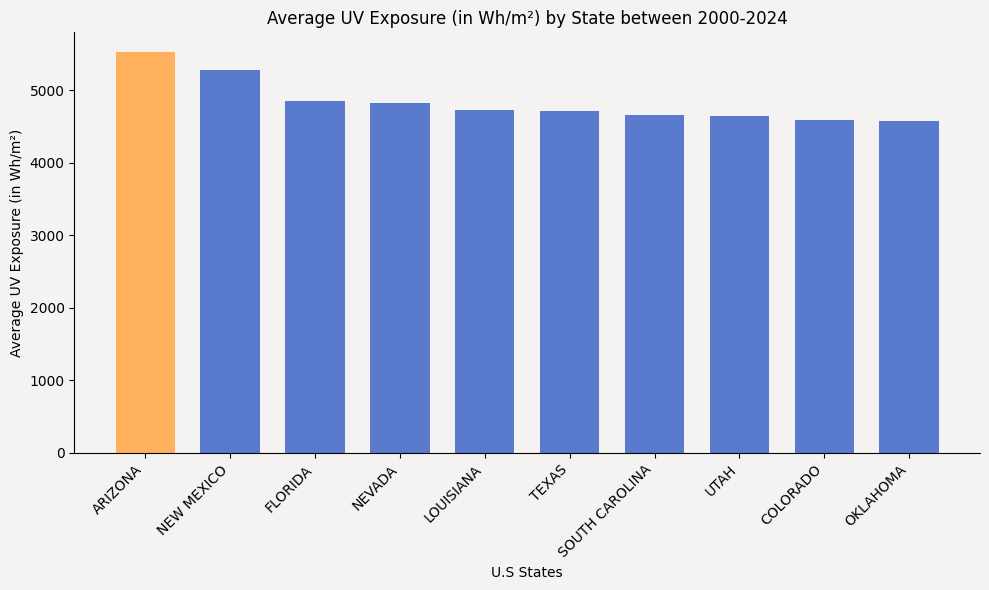

In [159]:
plt.figure(figsize=(10, 6),facecolor="#F5F2F2")
colors = ["#5A7ACD"]*len(result1)

max_index = result1['AVG_25YR'].idxmax()
highlight_position = result1.index.get_loc(max_index)
colors[highlight_position] = "#FEB05D"

plt.bar(result1['STATE_NAME'], result1['AVG_25YR'], color = colors, width=0.7)


ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_facecolor("#F5F2F2") # Change background color behind axes

plt.xlabel("U.S States")
plt.ylabel("Average UV Exposure (in Wh/m²)")
plt.title("Average UV Exposure (in Wh/m²) by State between 2000-2024")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.savefig("../images/barplot.png")
plt.show()